# Pathview Plus version comparison — August 12, 2026

**Comparison date:** August 12, 2026  
**Original bug audit:** August 10, 2026  
**Question:** Which of the August 10 findings can still be demonstrated in the v3.1.0 snapshot?

## Result from the saved files

The August 10 audit produced 86 unique finding IDs. I matched those IDs
to the saved v3.1.0 status report:

- **60 are fixed**;
- **19 are still reproducible**;
- **7 changed because the interface or documented behavior was replaced**;
- **0 were left unclassified**.

I kept “changed” separate because the old reproducer used an argument,
command, or dispatch path that v3 removed or replaced. I did not count
those rows as either fixed or still broken.

## What this notebook checks

I used this notebook to check the saved August 10 finding list, the v3.1.0
classification, the final v3 JUnit file, and the saved hsa04110 files.
The checks cover IDs, counts, priorities, hashes, image dimensions, and
the final CSV table. The last cells display the figures.

It does **not** rerun all 86 historical behavior checks or the 327-test v3
suite. Those source results are preserved in the proof folder. No live pathway
service is contacted here.

In [1]:
from pathlib import Path
import csv
import hashlib
import json
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Image as NotebookImage

DAY = Path.cwd()
if DAY.name == "notebooks":
    DAY = DAY.parent
assert (DAY / "data" / "august-10-findings.json").exists(), (
    "Run this notebook from the 08-12-2026 folder."
)

def load_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

old = load_json(DAY / "data" / "august-10-findings.json")
old_test_summary = load_json(DAY / "data" / "august-10-test-summary.json")
v3 = load_json(DAY / "data" / "v3-findings-status-source.json")
summary = load_json(DAY / "results" / "comparison-summary.json")

OLD_COMMIT = "07aee813375347bcc933ad21b4aed561dd7cd3bf"
NEW_COMMIT = "d4d45decec56e1ebec15cf04ae62ff944851780e"
assert old["scope"].endswith(OLD_COMMIT)
assert v3["previous_audited_commit"] == OLD_COMMIT
assert v3["current_commit"] == NEW_COMMIT
print("Loaded the frozen old and new evidence.")

Loaded the frozen old and new evidence.


## Software snapshots used by the audit

| Snapshot | Version | Exact commit |
|---|---|---|
| Old Pathview Plus | distribution 2.0.2; runtime string 2.0.0 | `07aee813375347bcc933ad21b4aed561dd7cd3bf` |
| New Pathview Plus | 3.1.0 | `d4d45decec56e1ebec15cf04ae62ff944851780e` |

The old version mismatch is itself `PV-BUG-001`, so I kept both version fields
instead of calling the old snapshot only “2.0.2.” The v3 package and
runtime both report 3.1.0.

In [2]:
versions = [
    {"snapshot": "Old", "package": "2.0.2", "runtime": "2.0.0", "commit": OLD_COMMIT},
    {"snapshot": "New", "package": "3.1.0", "runtime": "3.1.0", "commit": NEW_COMMIT},
]
display(versions)

[{'snapshot': 'Old',
  'package': '2.0.2',
  'runtime': '2.0.0',
  'commit': '07aee813375347bcc933ad21b4aed561dd7cd3bf'},
 {'snapshot': 'New',
  'package': '3.1.0',
  'runtime': '3.1.0',
  'commit': 'd4d45decec56e1ebec15cf04ae62ff944851780e'}]

## Check 1: every old finding has one status

The old JSON has one record for each finding. The v3 JSON has four status
lists. I compare the IDs before counting anything. A missing or repeated
ID stops this check instead of being silently ignored.

In [3]:
old_ids = [item["id"] for item in old["findings"]]
classified_pairs = [
    (finding_id, status)
    for status, identifiers in v3["classifications"].items()
    for finding_id in identifiers
]
classified_ids = [finding_id for finding_id, _ in classified_pairs]

duplicates = [item for item, count in Counter(classified_ids).items() if count > 1]
missing = sorted(set(old_ids) - set(classified_ids))
extra = sorted(set(classified_ids) - set(old_ids))

assert len(old_ids) == 86
assert len(set(old_ids)) == 86
assert not duplicates
assert not missing
assert not extra
assert len(classified_ids) == 86

print("Old unique findings:", len(old_ids))
print("Classified exactly once:", len(classified_ids))
print("Missing IDs:", missing)
print("Extra IDs:", extra)
print("Duplicate classifications:", duplicates)

Old unique findings: 86
Classified exactly once: 86
Missing IDs: []
Extra IDs: []
Duplicate classifications: []


## Check 2: count the three status groups

{'fixed': 60, 'still_reproducible': 19, 'changed': 7, 'not_retested': 0}
Fixed percentage: 69.8%


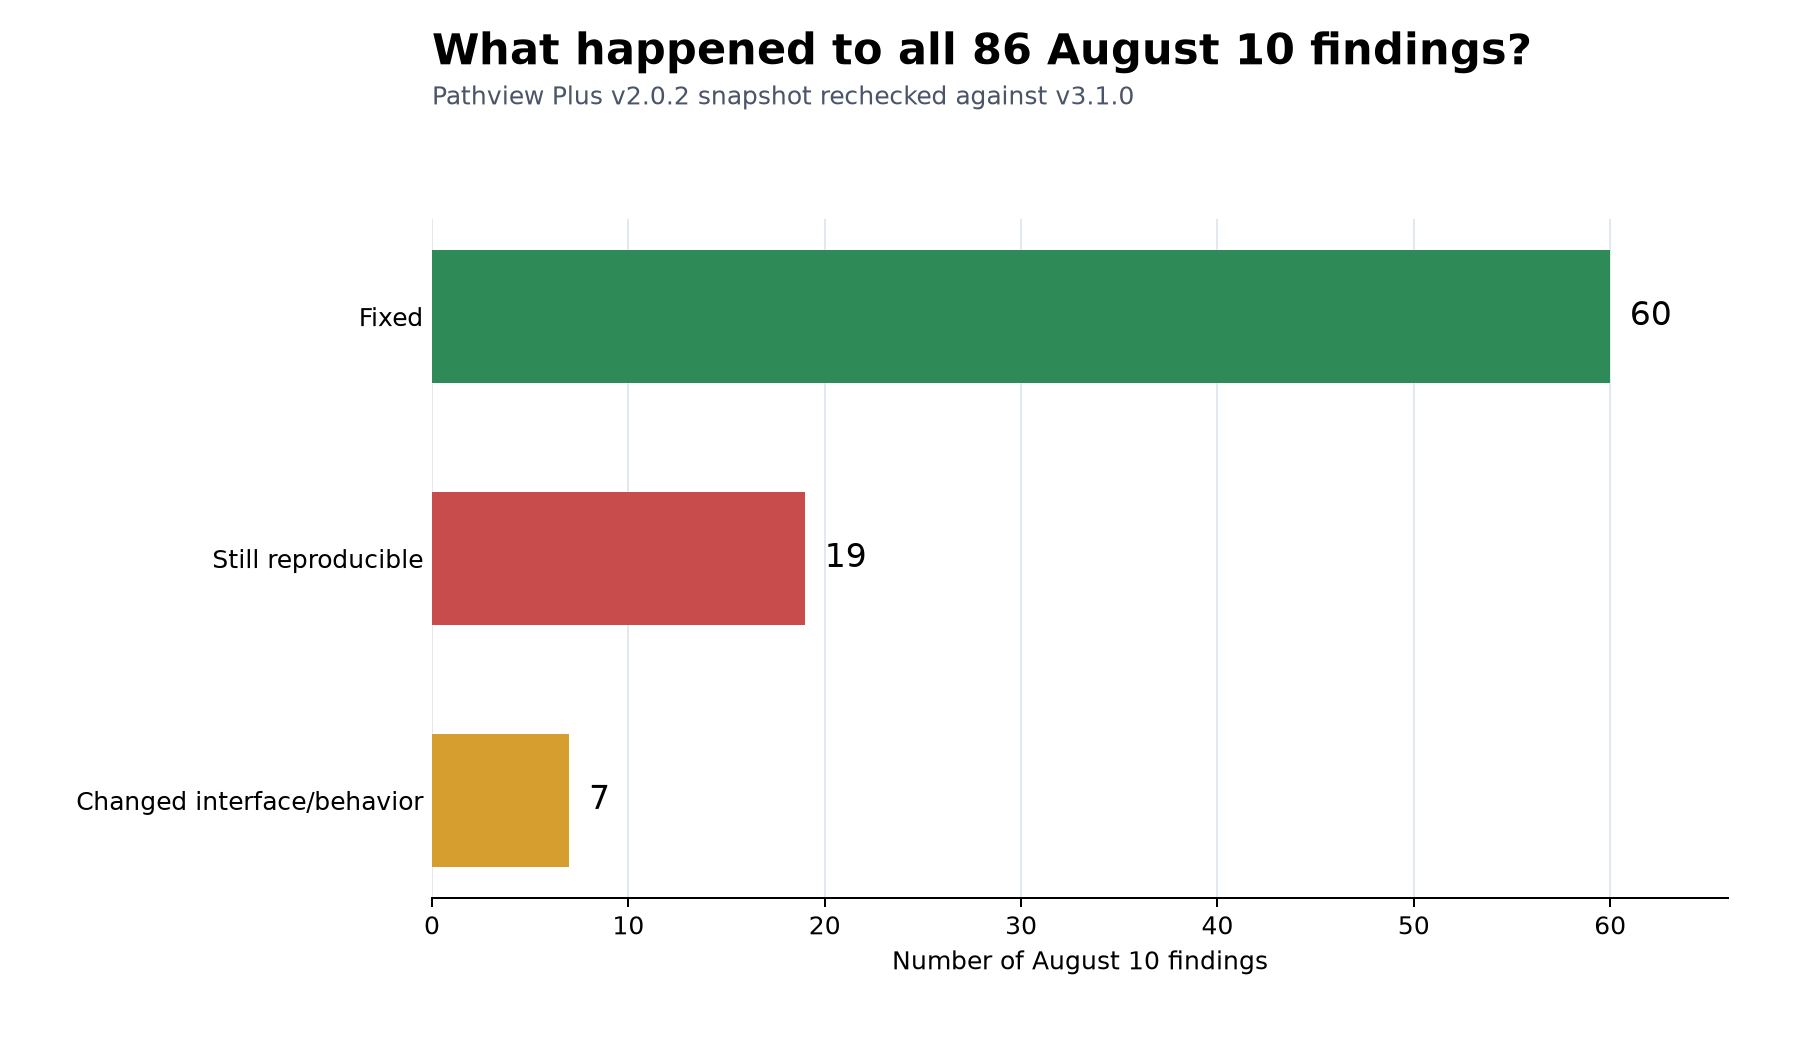

In [4]:
status_counts = {status: len(ids) for status, ids in v3["classifications"].items()}
expected = {"fixed": 60, "still_reproducible": 19, "changed": 7, "not_retested": 0}
assert status_counts == expected
assert sum(status_counts.values()) == 86
print(status_counts)
print(f"Fixed percentage: {100 * status_counts['fixed'] / 86:.1f}%")
display(NotebookImage(filename=str(DAY / "results" / "figures" / "01-overall-status.png"), width=850))

## Check 3: use the original priority labels

P1 was used in the August 10 audit for a main workflow or advertised
feature. P2/P3 covered smaller API details and edge cases. I kept those
old labels instead of assigning new priorities for v3.

{'P2/P3': {'fixed': 46, 'still_reproducible': 14, 'changed': 6},
 'P1': {'fixed': 14, 'still_reproducible': 5, 'changed': 1}}

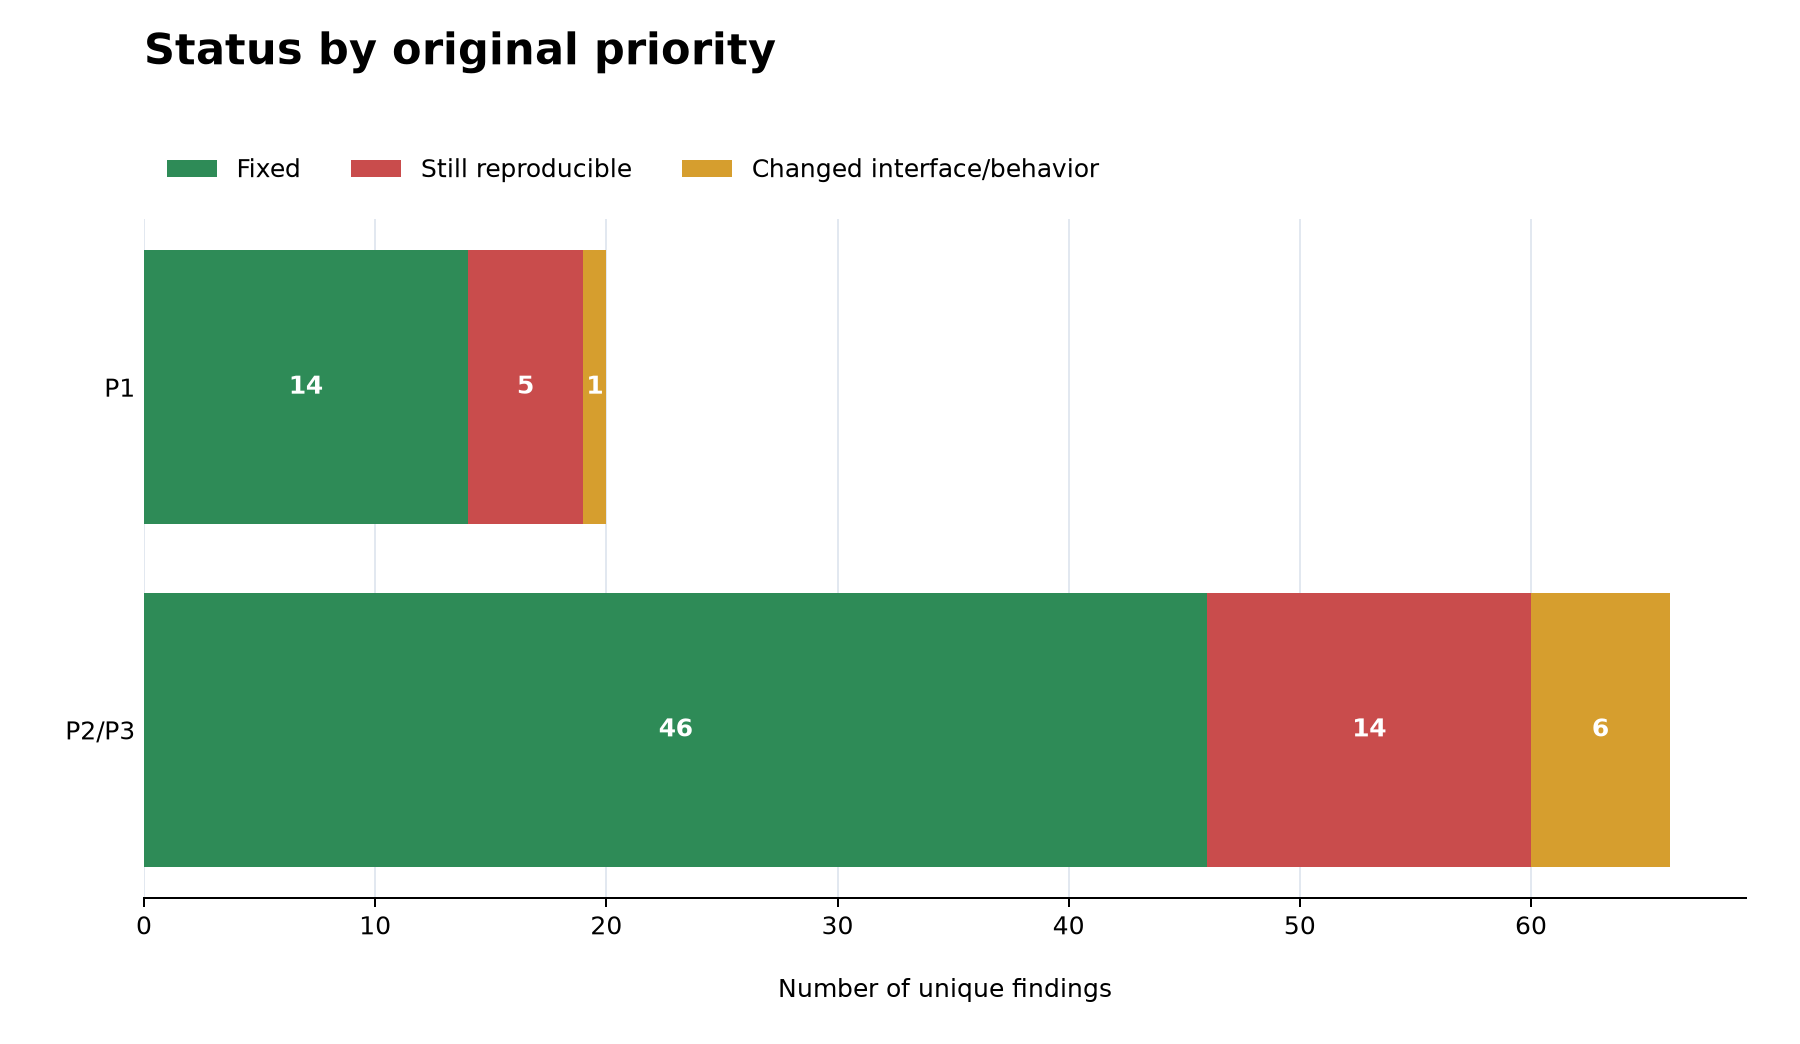

In [5]:
status_by_id = {finding_id: status for finding_id, status in classified_pairs}
priority_counts = defaultdict(Counter)
for item in old["findings"]:
    priority_counts[item["priority"]][status_by_id[item["id"]]] += 1

expected_priority = {
    "P1": {"fixed": 14, "still_reproducible": 5, "changed": 1},
    "P2/P3": {"fixed": 46, "still_reproducible": 14, "changed": 6},
}
for priority, expected_counts in expected_priority.items():
    assert {key: priority_counts[priority][key] for key in expected_counts} == expected_counts
display({priority: dict(counts) for priority, counts in priority_counts.items()})
display(NotebookImage(filename=str(DAY / "results" / "figures" / "02-priority-status.png"), width=850))

## The five original P1 findings that remain

This is the short list for the next review. The evidence comes from the
v3 adapted-recheck report, so it records what I observed rather than only
repeating the old description.

In [6]:
evidence = v3["adapted_recheck_evidence"]
remaining_p1 = [
    {
        "id": item["id"],
        "August 10 finding": item["summary"],
        "v3.1.0 evidence": evidence[item["id"]],
    }
    for item in old["findings"]
    if item["priority"] == "P1" and status_by_id[item["id"]] == "still_reproducible"
]
assert [item["id"] for item in remaining_p1] == [
    "PV-BUG-006", "PV-BUG-034", "PV-BUG-038", "PV-BUG-074", "PV-BUG-075"
]
display(remaining_p1)

[{'id': 'PV-BUG-006',
  'August 10 finding': 'map_null=False does not remove unmapped rows when a data table exists',
  'v3.1.0 evidence': 'With map_null=False and one matched gene, plot_data_gene still had 27 rows while only 1 row carried a value.'},
 {'id': 'PV-BUG-034',
  'August 10 finding': "bbox_inches='tight' crops/rescales native output instead of preserving KEGG pixels",
  'v3.1.0 evidence': 'A 120x100 native background saved as a 792x664 output with title, key, and signature disabled at dpi=100.'},
 {'id': 'PV-BUG-038',
  'August 10 finding': 'graph/PDF renderer uses only the first experiment color',
  'v3.1.0 evidence': 'Graph rendering reduced two colors per node to one node_color entry per node.'},
 {'id': 'PV-BUG-074',
  'August 10 finding': 'Reactome SBGN file exporter route is coded as /exporter/sbgn/{id}.sbgn instead of /exporter/event/{id}.sbgn',
  'v3.1.0 evidence': 'REACTOME_SBGN is still https://reactome.org/ContentService/exporter/sbgn and constructs .../sbgn/{id}

## Examples of the 60 absent old conditions

Here, “fixed” only means that the old condition was not observed in the v3
evidence attached to that ID. Examples include:

- offline species resolution;
- the composable `PathwayResult` and working highlight operations;
- preserved KEGG identifiers for biological highlighting;
- namespace-aware KGML and SBGN parsing;
- corrected compound coordinates and radii;
- pathway edges in SVG and graph outputs;
- safer aggregation and mapping;
- compound-only CLI use;
- PANTHER and SMPDB paths that now use the bundled SBGN collection instead of
  the old silent stubs.

In [7]:
fixed_ids = v3["classifications"]["fixed"]
important_fixed = [
    "PV-BUG-004", "PV-BUG-008", "PV-BUG-009", "PV-BUG-012",
    "PV-BUG-023", "PV-BUG-029", "PV-BUG-030", "PV-BUG-039",
    "PV-BUG-052", "PV-FEATURE-003", "PV-FEATURE-004",
]
assert all(item in fixed_ids for item in important_fixed)
print("Verified important fixed IDs:")
print(", ".join(important_fixed))

Verified important fixed IDs:
PV-BUG-004, PV-BUG-008, PV-BUG-009, PV-BUG-012, PV-BUG-023, PV-BUG-029, PV-BUG-030, PV-BUG-039, PV-BUG-052, PV-FEATURE-003, PV-FEATURE-004


## Seven findings that need a new v3 test

These seven are not included in either fixed or still reproducible. The old
API was replaced in color settings, ID normalization, routing, render
selection, CLI simulation, and non-KEGG SBGN workflows. Each one needs a
new test that uses the v3 interface before I can call it a pass or fail.

In [8]:
changed = v3["classifications"]["changed"]
assert changed == [
    "PV-BUG-005", "PV-BUG-016", "PV-BUG-018", "PV-BUG-047",
    "PV-BUG-067", "PV-BUG-077", "PV-FEATURE-007",
]
print("Changed interface/behavior IDs:")
print(", ".join(changed))

Changed interface/behavior IDs:
PV-BUG-005, PV-BUG-016, PV-BUG-018, PV-BUG-047, PV-BUG-067, PV-BUG-077, PV-FEATURE-007


## Saved image check: two-condition half-and-half rendering

These are the raw overlays saved during the two earlier runs. They use the
same three Entrez IDs and numeric values, although the condition names in
the tables changed. Both images are 1039 × 801. I use this as a visual
check of the saved workflow, not as a new run of both versions. It also
does not settle `PV-BUG-034`, which concerns the composed native output.

Old SHA-256: d2b201d22542536bec95bc8b38aeb922a93bd7285fbcb76761a99f6916739611
New SHA-256: d8aee09295dfc5e192fb58fead79cfd582a2eaf8ec09f8553eb3f7ed78f5cfb1
The images are not expected to be byte-identical: True


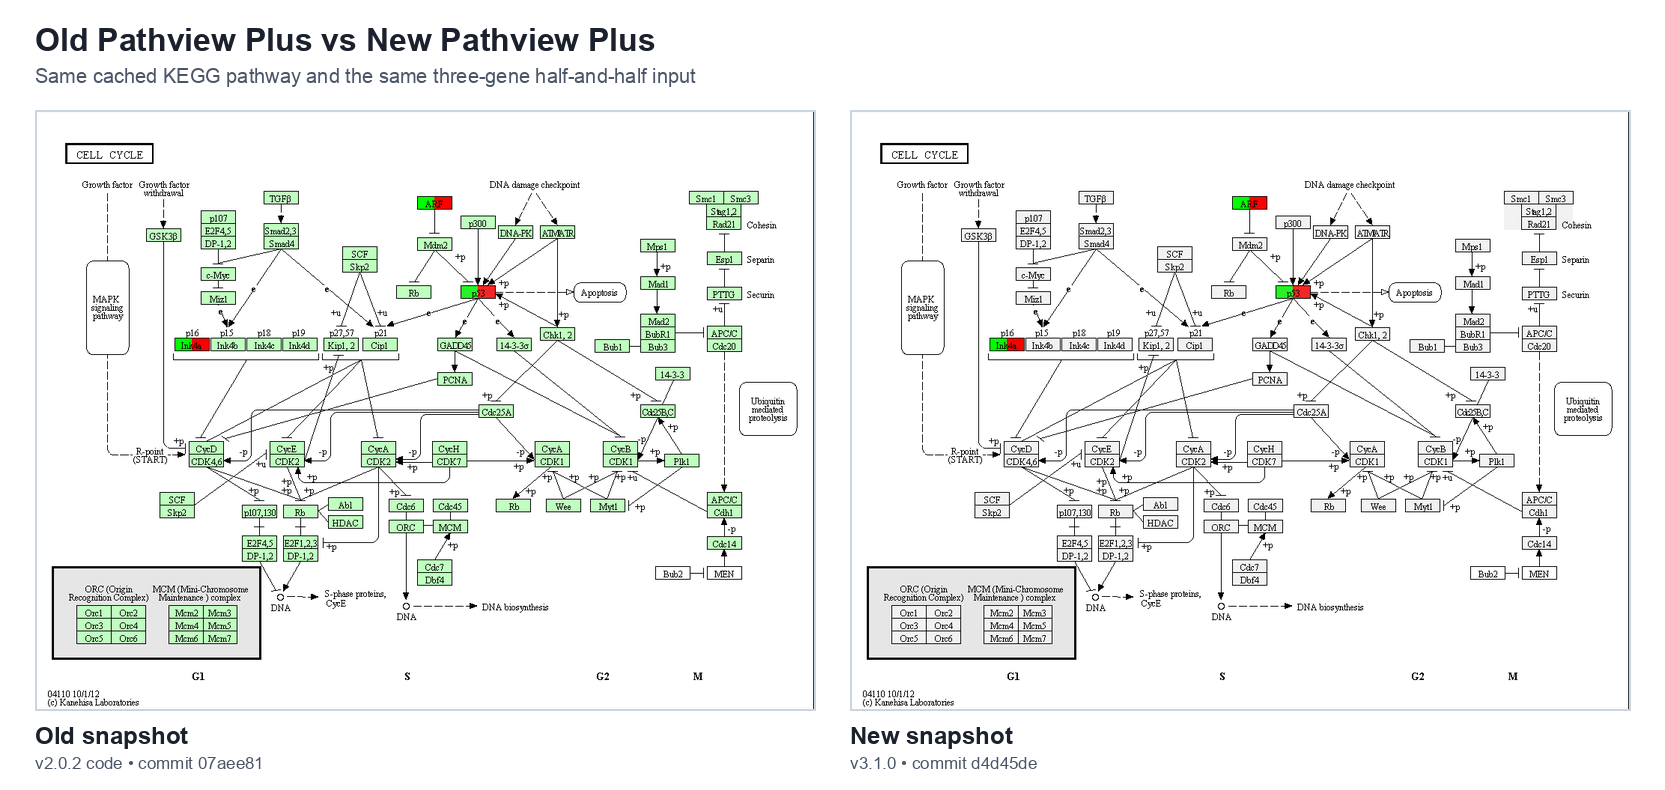

In [9]:
old_image = DAY / "data" / "old-v2-half-half.png"
new_image = DAY / "data" / "new-v3-half-half.png"
metrics = load_json(DAY / "results" / "tables" / "half-half-image-metrics.json")
assert Image.open(old_image).size == (1039, 801)
assert Image.open(new_image).size == (1039, 801)
assert metrics["same_dimensions"] is True
print("Old SHA-256:", sha256(old_image))
print("New SHA-256:", sha256(new_image))
print("The images are not expected to be byte-identical:", sha256(old_image) != sha256(new_image))
display(NotebookImage(filename=str(DAY / "results" / "figures" / "03-old-vs-new-half-half.png"), width=1050))

## Check 4: the pathway files are the same

I compare the SHA-256 hashes of the old and new hsa04110 XML and PNG files.
The matching hashes mean the pathway files themselves did not change
between the saved runs.

In [10]:
root = DAY.parent
old_xml = root / "08-10-2026" / "pathveiw bug checks" / "results" / "evidence" / "official-hsa04110" / "hsa04110.xml"
old_png = root / "08-10-2026" / "pathveiw bug checks" / "results" / "evidence" / "official-hsa04110" / "hsa04110.png"
new_xml = root / "08-11-2026" / "sources" / "pathview-plus" / "tests" / "fixtures" / "hsa04110.xml"
new_png = root / "08-11-2026" / "sources" / "pathview-plus" / "tests" / "fixtures" / "hsa04110.png"
frozen = {
    "XML hashes match": sha256(old_xml) == sha256(new_xml),
    "PNG hashes match": sha256(old_png) == sha256(new_png),
    "XML SHA-256": sha256(old_xml),
    "PNG SHA-256": sha256(old_png),
}
assert frozen["XML hashes match"] and frozen["PNG hashes match"]
display(frozen)

{'XML hashes match': True,
 'PNG hashes match': True,
 'XML SHA-256': 'c910e7727818e18219d39305ed10387d858e2319d246bf5b3778b0c51e906978',
 'PNG SHA-256': '7f927c29e1496d0fa9f150f48570f96a34e7487957e7a38ce27493a775a4e2d9'}

## Check 5: keep the two test suites separate

The August 10 audit and the v3 upstream suite have different test lists, so
I do not treat their pass percentages as a before/after score. The fair
comparison is the status of the same 86 old IDs. I use the JUnit file here
only to check that the saved v3 run says 327 collected, 321 passed, 6
skipped, and 0 failed.

In [11]:
assert old_test_summary == {
    "total_test_cases": 239,
    "status_counts": {"FEATURE_GAP": 7, "KNOWN_BUG": 89, "PASS": 143},
    "unique_reproduced_findings": 86,
    "unique_confirmed_bug_ids": 79,
    "unique_feature_gap_ids": 7,
    "unexpected_failures": 0,
    "total_seconds": old_test_summary["total_seconds"],
}

junit_root = ET.parse(DAY / "results" / "proof" / "v3-upstream-final-junit.xml").getroot()
junit = junit_root if junit_root.tag == "testsuite" else junit_root.find("testsuite")
assert junit is not None
v3_tests = {
    "collected": int(junit.attrib["tests"]),
    "failed": int(junit.attrib["failures"]),
    "errors": int(junit.attrib["errors"]),
    "skipped": int(junit.attrib["skipped"]),
}
v3_tests["passed"] = v3_tests["collected"] - v3_tests["failed"] - v3_tests["errors"] - v3_tests["skipped"]
assert v3_tests == {"collected": 327, "failed": 0, "errors": 0, "skipped": 6, "passed": 321}
display({"old_external_audit": old_test_summary, "new_upstream_suite": v3_tests})

{'old_external_audit': {'total_test_cases': 239,
  'status_counts': {'FEATURE_GAP': 7, 'KNOWN_BUG': 89, 'PASS': 143},
  'unique_reproduced_findings': 86,
  'unique_confirmed_bug_ids': 79,
  'unique_feature_gap_ids': 7,
  'unexpected_failures': 0,
  'total_seconds': 11.846},
 'new_upstream_suite': {'collected': 327,
  'failed': 0,
  'errors': 0,
  'skipped': 6,
  'passed': 321}}

## Check 6: inspect the complete table

The final CSV has one row for each old finding. This is the file I would
search when someone asks about a particular `PV-BUG-*` or
`PV-FEATURE-*` ID.

In [12]:
with (DAY / "results" / "tables" / "all-86-findings.csv").open(encoding="utf-8") as stream:
    rows = list(csv.DictReader(stream))
assert len(rows) == 86
assert Counter(row["v3_status"] for row in rows) == Counter({
    "fixed": 60, "still_reproducible": 19, "changed": 7
})
print("Rows:", len(rows))
display(rows[:8])
print("Full table: results/tables/all-86-findings.csv")

Rows: 86


[{'id': 'PV-BUG-001',
  'old_priority': 'P2/P3',
  'old_kind': 'reproduced_bug',
  'old_summary': 'setup.py/distribution is 2.0.2 but pathview.__version__ is 2.0.0',
  'v3_status': 'fixed',
  'v3_status_label': 'Fixed',
  'v3_evidence': 'The old failure condition is absent in the v3 test, adapted recheck, or direct source audit.',
  'old_test_case_count': '1',
  'old_tests': 'tests.test_public_core::test_distribution_and_runtime_versions_match'},
 {'id': 'PV-BUG-002',
  'old_priority': 'P2/P3',
  'old_kind': 'reproduced_bug',
  'old_summary': "--no-kegg-native with output_format='png' silently writes graph PDF",
  'v3_status': 'fixed',
  'v3_status_label': 'Fixed',
  'v3_evidence': 'The old failure condition is absent in the v3 test, adapted recheck, or direct source audit.',
  'old_test_case_count': '1',
  'old_tests': 'tests.test_public_core::test_non_native_png_request_produces_png'},
 {'id': 'PV-BUG-003',
  'old_priority': 'P2/P3',
  'old_kind': 'reproduced_bug',
  'old_summary': '

Full table: results/tables/all-86-findings.csv


## What I would do next

The v3 evidence removes 60 of the 86 old conditions from the reproduced list,
but the audit is not finished. Nineteen conditions remain reproducible and
seven old tests need replacements because their contracts changed.

I would start with `PV-BUG-006`, `PV-BUG-034`, `PV-BUG-038`, `PV-BUG-074`,
and `PV-BUG-075`, then add v3-native regression tests for the other 14
reproducible findings and the seven changed interfaces.